Objetivo:
Previsão de Preços de Casas

### Crie um dataset único a partir dos datasets em anexo.

### 1. Análise e entendimento dos dados
- Explique o que representam as principais variáveis.
- Mostre correlações, outliers e padrões relevantes.
- Descreva como combinou os dados físicos e demográficos.

### 2. Desenvolvimento do modelo de Machine Learning
Inclua:
- **a. Variáveis importantes:** quais features foram mais relevantes e por quê.
- **b. Escolha do modelo:** escolha e implemente um modelo para resolver o problema --- Lembre-se que a NP1 englobou até MLP.
- **c. Generalização:** como você garante que o modelo generaliza bem para novos dados (ex: uso de *train/test split*, *cross-validation*, regularização, etc.).

O aluno deve entregar um relatório explicando os passos solicitados e o código contando todas as etapas de EDA, Pré-Processamento, Implementação do Modelo.

In [82]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [83]:
df_demog = pd.read_csv('zipcode_demographics.csv', delimiter=',')
df_house = pd.read_csv('kc_house_data.csv', delimiter=',')
df_future = pd.read_csv('future_unseen_examples.csv', delimiter=',')

df = df_house.merge(df_demog, on='zipcode', how='left')
df.to_csv('dataframe.csv', index=False)

print(df.shape)
print(df.isnull().sum())
print(df.describe())

(21613, 47)
id                        0
date                      0
price                     0
bedrooms                  0
bathrooms                 0
sqft_living               0
sqft_lot                  0
floors                    0
waterfront                0
view                      0
condition                 0
grade                     0
sqft_above                0
sqft_basement             0
yr_built                  0
yr_renovated              0
zipcode                   0
lat                       0
long                      0
sqft_living15             0
sqft_lot15                0
ppltn_qty                 0
urbn_ppltn_qty            0
sbrbn_ppltn_qty           0
farm_ppltn_qty            0
non_farm_qty              0
medn_hshld_incm_amt       0
medn_incm_per_prsn_amt    0
hous_val_amt              0
edctn_less_than_9_qty     0
edctn_9_12_qty            0
edctn_high_schl_qty       0
edctn_some_clg_qty        0
edctn_assoc_dgre_qty      0
edctn_bchlr_dgre_qty      0
edctn_pr

In [84]:
# renovated: True / False
df['renovated'] = df['yr_renovated'] > 0
# month
df['month_sold'] = df['date'].str[4:6].astype(int)
# age
df['yr_sold'] = df['date'].str[:4].astype(int)
df['age'] = df['yr_sold'] - df['yr_built']
# basement: True / False
df['basement'] = df['sqft_basement'] > 0
# diferença entre a regiao
df['dif_sqft_living'] = df['sqft_living'] - df['sqft_living15']
df['dif_sqft_lot'] = df['sqft_lot'] - df['sqft_lot15']
# substituindo 0's por NaN onde for viável
df['yr_renovated'] = df['yr_renovated'].replace(0, np.nan)

print(df.head)

<bound method NDFrame.head of                id             date     price  bedrooms  bathrooms  \
0      7129300520  20141013T000000  221900.0         3       1.00   
1      6414100192  20141209T000000  538000.0         3       2.25   
2      5631500400  20150225T000000  180000.0         2       1.00   
3      2487200875  20141209T000000  604000.0         4       3.00   
4      1954400510  20150218T000000  510000.0         3       2.00   
...           ...              ...       ...       ...        ...   
21608   263000018  20140521T000000  360000.0         3       2.50   
21609  6600060120  20150223T000000  400000.0         4       2.50   
21610  1523300141  20140623T000000  402101.0         2       0.75   
21611   291310100  20150116T000000  400000.0         3       2.50   
21612  1523300157  20141015T000000  325000.0         2       0.75   

       sqft_living  sqft_lot  floors  waterfront  view  ...  per_assoc  \
0             1180      5650     1.0           0     0  ...        

In [85]:
df.drop(columns=['date', 'sqft_living15', 'sqft_lot15', 'zipcode'], inplace=True)
print(df.shape)
print(df.isnull().sum())
print(df.describe())

(21613, 50)
id                            0
price                         0
bedrooms                      0
bathrooms                     0
sqft_living                   0
sqft_lot                      0
floors                        0
waterfront                    0
view                          0
condition                     0
grade                         0
sqft_above                    0
sqft_basement                 0
yr_built                      0
yr_renovated              20699
lat                           0
long                          0
ppltn_qty                     0
urbn_ppltn_qty                0
sbrbn_ppltn_qty               0
farm_ppltn_qty                0
non_farm_qty                  0
medn_hshld_incm_amt           0
medn_incm_per_prsn_amt        0
hous_val_amt                  0
edctn_less_than_9_qty         0
edctn_9_12_qty                0
edctn_high_schl_qty           0
edctn_some_clg_qty            0
edctn_assoc_dgre_qty          0
edctn_bchlr_dgre_qty        

id                          0
price                     406
bedrooms                   75
bathrooms                 187
sqft_living               248
sqft_lot                  347
floors                      8
waterfront                163
view                      829
condition                  30
grade                     136
sqft_above                254
sqft_basement             247
yr_built                    0
yr_renovated               10
lat                         0
long                      233
ppltn_qty                 274
urbn_ppltn_qty            274
sbrbn_ppltn_qty           221
farm_ppltn_qty            234
non_farm_qty              352
medn_hshld_incm_amt        50
medn_incm_per_prsn_amt     50
hous_val_amt              332
edctn_less_than_9_qty     508
edctn_9_12_qty            274
edctn_high_schl_qty       274
edctn_some_clg_qty        229
edctn_assoc_dgre_qty      274
edctn_bchlr_dgre_qty        0
edctn_prfsnl_qty          583
per_urbn                  854
per_sbrbn 

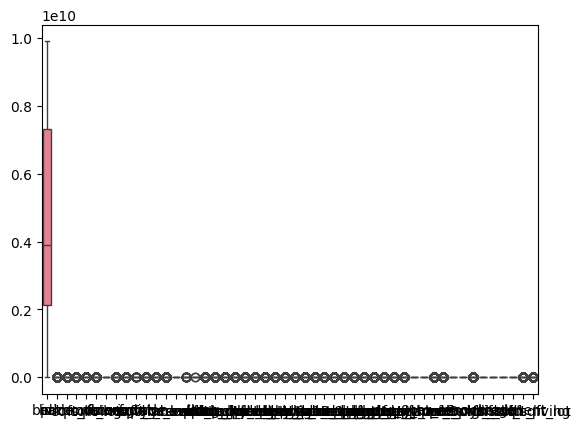

In [86]:
# outliers
z_scores = np.abs((df - df.mean()) / df.std())
outliers = (z_scores > 3)
print(outliers.sum())

print('\n')

df_num = df.select_dtypes(include=['float64','int64'])
Q1 = df_num.quantile(0.25)
Q3 = df_num.quantile(0.75)
IQR = Q3 - Q1
outliers = ((df_num < (Q1 - 1.5 * IQR)) | (df_num > (Q3 + 1.5 * IQR)))
print(outliers.sum())

sns.boxplot(data=df)
plt.show()

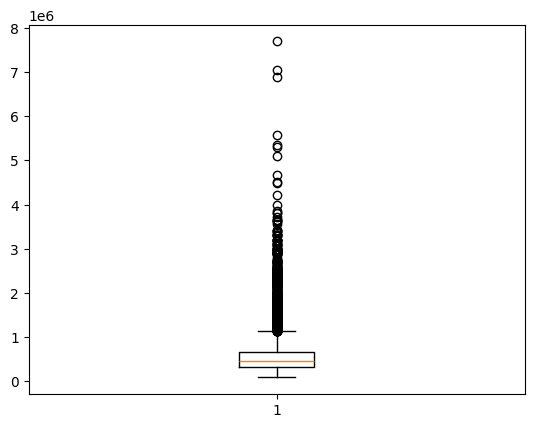

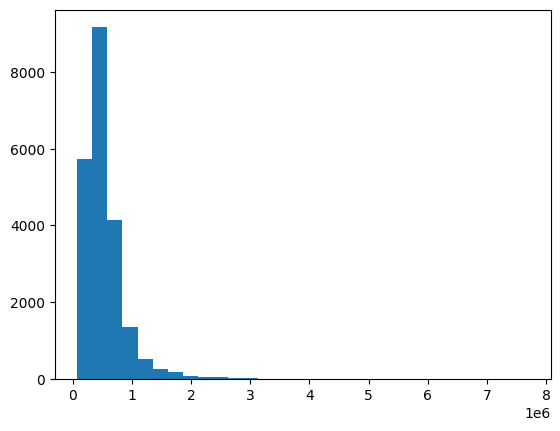

In [87]:
# outlier de price
plt.boxplot(df['price'])
plt.show()

plt.hist(df['price'], bins=30)
plt.show()

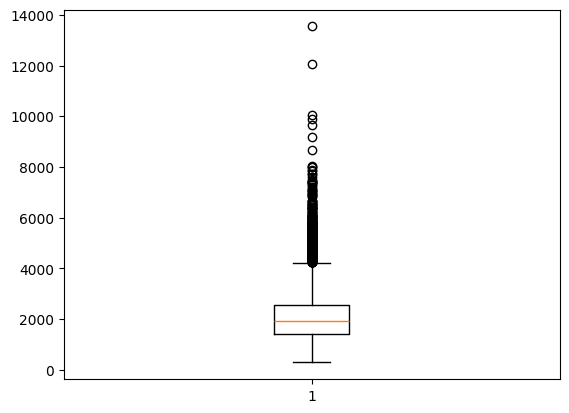

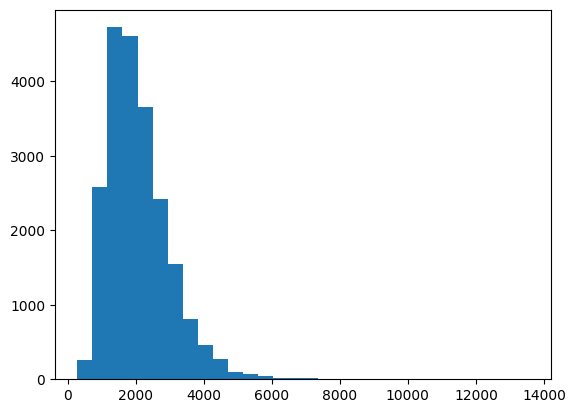

In [88]:
# outlier de sqft_living
plt.boxplot(df['sqft_living'])
plt.show()

plt.hist(df['sqft_living'], bins=30)
plt.show()

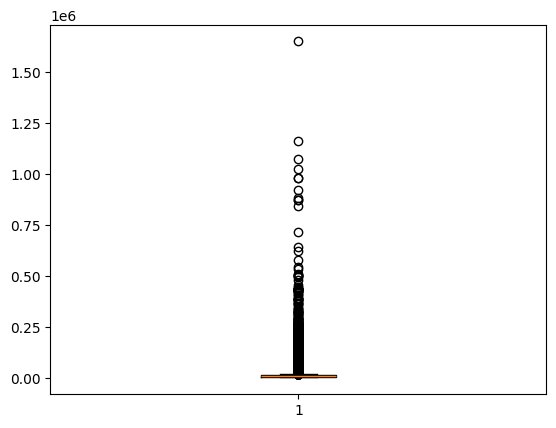

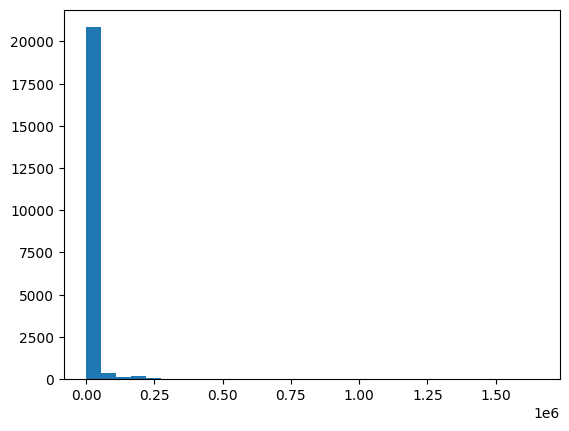

In [89]:
# outlier de sqft_lot
plt.boxplot(df['sqft_lot'])
plt.show()

plt.hist(df['sqft_lot'], bins=30)
plt.show()

                              id     price  bedrooms  bathrooms  sqft_living  \
id                      1.000000 -0.016762  0.001286   0.005160    -0.012258   
price                  -0.016762  1.000000  0.308350   0.525138     0.702035   
bedrooms                0.001286  0.308350  1.000000   0.515884     0.576671   
bathrooms               0.005160  0.525138  0.515884   1.000000     0.754665   
sqft_living            -0.012258  0.702035  0.576671   0.754665     1.000000   
sqft_lot               -0.132109  0.089661  0.031703   0.087740     0.172826   
floors                  0.018525  0.256794  0.175429   0.500653     0.353949   
waterfront             -0.002721  0.266369 -0.006582   0.063744     0.103818   
view                    0.011592  0.397293  0.079532   0.187737     0.284611   
condition              -0.023783  0.036362  0.028472  -0.124982    -0.058753   
grade                   0.008130  0.667434  0.356967   0.664983     0.762704   
sqft_above             -0.010842  0.6055

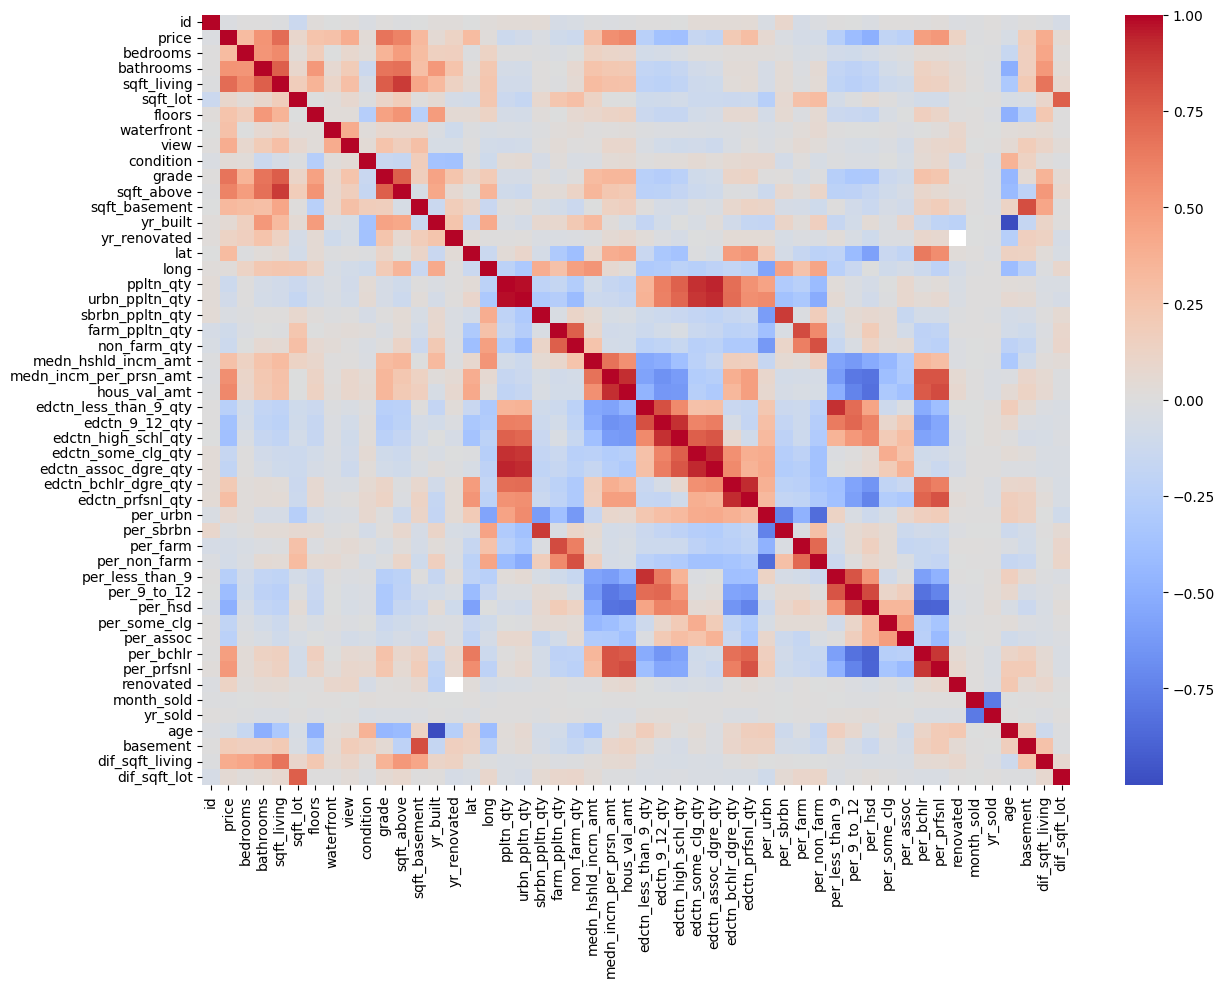

In [90]:
print(df.corr())

plt.figure(figsize=(14,10))
sns.heatmap(df.corr(numeric_only=True), cmap='coolwarm')
plt.show()